# Загрузка данных и первичный EDA: dialogsum-ru

**Цель ноутбука.** Подготовить отправную точку для дальнейшей работы по теме магистерской диссертации «Семантический анализ русскоязычных диалогов для задачи распознавания намерений с улучшением на базе предобученных моделей».

**Что делает ноутбук:**

- подключает Google Drive в среде Google Colab;
- загружает датасет `d0rj/dialogsum-ru` из Hugging Face;
- исследует структуру датасета (сплиты, поля, примеры);
- считает базовую статистику по длинам диалогов и резюме;
- сохраняет таблицы (`results/tables/`) и графики (`results/figures/`) на Google Drive;
- выводит несколько случайных диалогов для последующего проектирования схемы интентов.

Ноутбук рассчитан на запуск в Google Colab.

## 1. Подключение Google Drive и пути к артефактам

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/russian-dialogue-intent-thesis"
DATA_DIR = f"{BASE_DIR}/data"
RESULTS_DIR = f"{BASE_DIR}/results"
TABLES_DIR = f"{RESULTS_DIR}/tables"
FIGURES_DIR = f"{RESULTS_DIR}/figures"

for path in [BASE_DIR, DATA_DIR, RESULTS_DIR, TABLES_DIR, FIGURES_DIR]:
    os.makedirs(path, exist_ok=True)
    print(f"OK: {path}")

OK: /content/drive/MyDrive/russian-dialogue-intent-thesis
OK: /content/drive/MyDrive/russian-dialogue-intent-thesis/data
OK: /content/drive/MyDrive/russian-dialogue-intent-thesis/results
OK: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables
OK: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures


## 2. Установка и импорт зависимостей

In [3]:
# При необходимости раскомментируйте установку зависимостей в Google Colab.
# !pip install -q datasets pandas numpy matplotlib seaborn

In [4]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")

## 3. Загрузка датасета `d0rj/dialogsum-ru`

In [5]:
DATASET_NAME = "d0rj/dialogsum-ru"
dataset = load_dataset(DATASET_NAME)
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-bcc43b46acda40(…):   0%|          | 0.00/9.29M [00:00<?, ?B/s]

data/validation-00000-of-00001-7e263d81d(…):   0%|          | 0.00/372k [00:00<?, ?B/s]

data/test-00000-of-00001-2f13615b955ea94(…):   0%|          | 0.00/487k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12460 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})

In [6]:
# Сплиты и их размеры
split_sizes = {split: len(dataset[split]) for split in dataset.keys()}
print("Сплиты и размеры:")
for split, size in split_sizes.items():
    print(f"  {split}: {size}")

first_split = next(iter(dataset.keys()))
print("\nКолонки сплита", first_split, ":", dataset[first_split].column_names)

Сплиты и размеры:
  train: 12460
  validation: 500
  test: 1500

Колонки сплита train : ['id', 'dialogue', 'summary', 'topic']


In [7]:
# Несколько примеров из первого доступного сплита
n_examples = 3
for i, example in enumerate(dataset[first_split].select(range(min(n_examples, len(dataset[first_split])))) ):
    print(f"--- Пример {i + 1} ---")
    for key, value in example.items():
        preview = str(value)
        if len(preview) > 500:
            preview = preview[:500] + "…"
        print(f"{key}: {preview}")
    print()

--- Пример 1 ---
id: train_0
dialogue: #Person1#: Привет, мистер Смит. Я доктор Хокинс. Почему ты здесь сегодня?
#Person2#: Я решил, что было бы неплохо пройти обследование.
#Person1#: Да ну, у тебя его уже 5 лет нет. Вы должны иметь один каждый год.
#Person2#: Я знаю. Я так понимаю, если ничего страшного, то зачем идти к врачу?
#Person1#: Что ж, лучший способ избежать серьезных заболеваний — узнать о них заранее. Так что старайтесь приезжать хотя бы раз в год для вашего же блага.
#Person2#: Хорошо.
#Person1#: Дай-ка сюда посмотреть.…
summary: Мистер Смит проходит обследование, и доктор Хокинс советует ему проходить его каждый год. Хокинс расскажет об их занятиях и лекарствах, которые помогут мистеру Смиту бросить курить.
topic: пройти обследование

--- Пример 2 ---
id: train_1
dialogue: #Person1#: Здравствуйте, миссис Паркер, как дела?
#Person2#: Здравствуйте, доктор Питерс. Просто отлично спасибо. Рикки и я здесь за его вакцинами.
#Person1#: Очень хорошо. Давайте посмотрим, согласно 

## 4. Преобразование сплитов в DataFrame и расчёт длин

In [8]:
def safe_get(example, *keys, default=""):
    """Берёт первое непустое значение по списку возможных ключей."""
    for key in keys:
        if key in example and example[key] is not None:
            return example[key]
    return default


def extract_utterances(dialogue):
    """Robustly разбивает поле диалога на отдельные реплики.

    Поддерживает строку (разделённую переносами строк) и список (строк или dict).
    Возвращает list[str]. На неожиданный формат не падает.
    """
    if dialogue is None:
        return []
    if isinstance(dialogue, str):
        parts = [line.strip() for line in dialogue.splitlines() if line.strip()]
        return parts
    if isinstance(dialogue, list):
        result = []
        for item in dialogue:
            if isinstance(item, str):
                text = item.strip()
            elif isinstance(item, dict):
                text = str(item.get("text") or item.get("utterance") or item.get("value") or item).strip()
            else:
                text = str(item).strip()
            if text:
                result.append(text)
        return result
    return [str(dialogue).strip()]


def dialogue_to_text(dialogue):
    return "\n".join(extract_utterances(dialogue))


def count_words(text):
    if not text:
        return 0
    return len(str(text).split())


def first_token(text):
    if not text:
        return ""
    tokens = str(text).split()
    return tokens[0] if tokens else ""

In [9]:
def split_to_dataframe(hf_split, split_name):
    rows = []
    for example in hf_split:
        dialogue_field = safe_get(example, "dialogue", "dialog", default="")
        summary_field = safe_get(example, "summary", default="")
        utterances = extract_utterances(dialogue_field)
        dialogue_text = "\n".join(utterances)
        rows.append({
            "split": split_name,
            "id": safe_get(example, "id", "fname", default=""),
            "dialogue": dialogue_text,
            "summary": str(summary_field) if summary_field is not None else "",
            "topic": safe_get(example, "topic", default=""),
            "num_utterances": len(utterances),
            "dialogue_len_chars": len(dialogue_text),
            "dialogue_len_words": count_words(dialogue_text),
            "summary_len_chars": len(str(summary_field) if summary_field is not None else ""),
            "summary_len_words": count_words(summary_field),
            "first_utterance_token": first_token(utterances[0]) if utterances else "",
        })
    return pd.DataFrame(rows)


dfs = {split: split_to_dataframe(dataset[split], split) for split in dataset.keys()}
df_all = pd.concat(dfs.values(), ignore_index=True)
df_all.head()

,split,id,dialogue,summary,topic,num_utterances,dialogue_len_chars,dialogue_len_words,summary_len_chars,summary_len_words,first_utterance_token
0,train,train_0,"#Person1#: Привет, мистер Смит. Я доктор Хокин...","Мистер Смит проходит обследование, и доктор Хо...",пройти обследование,12,971,152,181,26,#Person1#:
1,train,train_1,"#Person1#: Здравствуйте, миссис Паркер, как де...",Миссис Паркер берет Рики на прививки. Доктор П...,вакцина,7,839,124,98,15,#Person1#:
2,train,train_2,"#Person1#: Простите, вы не видели связку ключе...",#Person1# ищет набор ключей и просит #Person2#...,найти ключи,10,458,70,63,10,#Person1#:
3,train,train_3,"#Person1#: Почему ты не сказал мне, что у тебя...","#Person1# злится, потому что #Person2# не сказ...",иметь девушку,11,554,91,109,18,#Person1#:
4,train,train_4,"#Person1#: Ватсап, дамы! Ты хорошо выглядишь с...",Малик приглашает Никки на танец. Никки соглаша...,танец,7,508,79,107,17,#Person1#:


## 5. Базовый EDA и сохранение артефактов

In [10]:
# Размеры сплитов
split_sizes_df = pd.DataFrame(
    [{"split": split, "size": len(df)} for split, df in dfs.items()]
)
split_sizes_df.to_csv(os.path.join(TABLES_DIR, "split_sizes.csv"), index=False)
split_sizes_df

,split,size
0,train,12460
1,validation,500
2,test,1500


In [11]:
# Описательная статистика по длинам диалогов
dialogue_cols = ["num_utterances", "dialogue_len_chars", "dialogue_len_words"]
dialogue_stats = df_all.groupby("split")[dialogue_cols].describe()
dialogue_stats.to_csv(os.path.join(TABLES_DIR, "dialogue_length_stats.csv"))
dialogue_stats

num_utterances                                                 \
                    count      mean       std  min  25%  50%   75%   max   
split                                                                      
test               1500.0  9.706000  4.987198  2.0  7.0  9.0  12.0  65.0   
train             12460.0  9.494222  4.157106  2.0  7.0  9.0  12.0  61.0   
validation          500.0  9.380000  3.992428  2.0  6.0  9.0  12.0  29.0   

           dialogue_len_chars              ...                  \
                        count        mean  ...     75%     max   
split                                      ...                   
test                   1500.0  757.092000  ...  954.25  4348.0   
train                 12460.0  737.455136  ...  916.25  5158.0   
validation              500.0  726.358000  ...  906.50  2587.0   

           dialogue_len_words                                             \
                        count        mean        std   min    25%    50%   
split                                                                      
test                   1500.0  115.954000  66.534556  29.0  70.75  103.5   
train                 12460.0  112.827448  62.333805  25.0  72.00   99.0   
validation              500.0  111.420000  58.412118  28.0  71.75   96.5   

                          
              75%    max  
split                     
test        144.0  680.0  
train       140.0  869.0  
validation  139.0  415.0  

[3 rows x 24 columns]

In [12]:
# Описательная статистика по длинам резюме
summary_cols = ["summary_len_chars", "summary_len_words"]
summary_stats = df_all.groupby("split")[summary_cols].describe()
summary_stats.to_csv(os.path.join(TABLES_DIR, "summary_length_stats.csv"))
summary_stats

summary_len_chars                                             \
                       count        mean        std   min    25%    50%   
split                                                                     
test                  1500.0  116.691333  54.377281  23.0  78.75  108.0   
train                12460.0  145.055056  69.119577  30.0  97.00  132.0   
validation             500.0  134.270000  63.987639  40.0  88.00  119.0   

                           summary_len_words                                  \
               75%     max             count       mean       std  min   25%   
split                                                                          
test        142.00   491.0            1500.0  16.286000  7.806546  4.0  11.0   
train       178.25  1073.0           12460.0  20.276244  9.830317  4.0  13.0   
validation  166.25   458.0             500.0  18.500000  9.048190  5.0  12.0   

                               
             50%   75%    max  
split                          
test        15.0  20.0   70.0  
train       18.0  25.0  136.0  
validation  16.0  23.0   61.0

In [13]:
# Топ-20 наиболее частых первых токенов реплик (по всем сплитам)
top_first_tokens = (
    df_all["first_utterance_token"]
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(20)
    .rename_axis("first_token")
    .reset_index(name="count")
)
top_first_tokens.to_csv(os.path.join(TABLES_DIR, "top20_first_tokens.csv"), index=False)
top_first_tokens

,first_token,count
0,#Person1#:,14434
1,#Человек1#:,22
2,#Лицо1#:,4


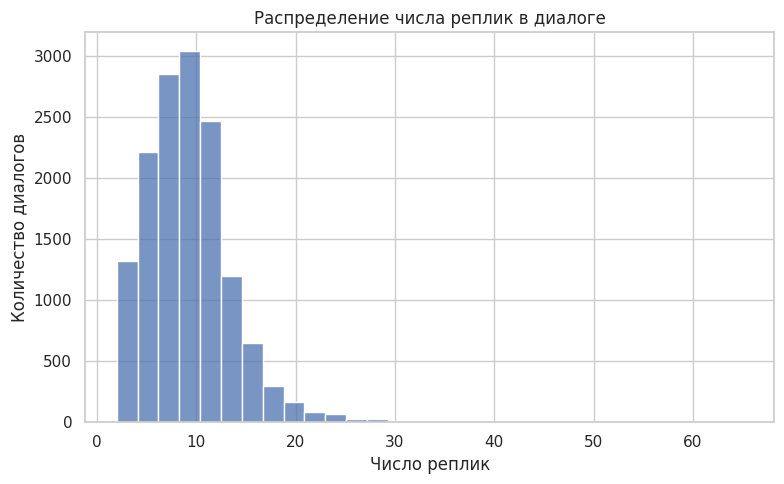

In [14]:
# Гистограмма числа реплик
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df_all, x="num_utterances", bins=30, ax=ax)
ax.set_title("Распределение числа реплик в диалоге")
ax.set_xlabel("Число реплик")
ax.set_ylabel("Количество диалогов")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "hist_num_utterances.png"), dpi=150)
plt.show()

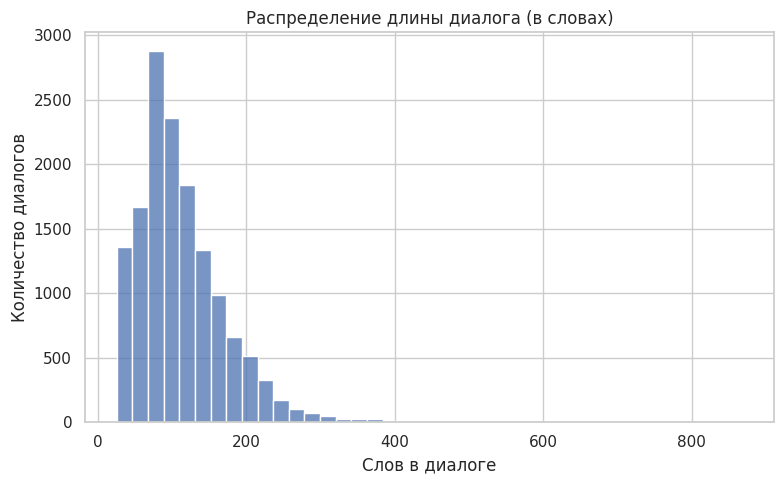

In [15]:
# Гистограмма длины диалога в словах
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df_all, x="dialogue_len_words", bins=40, ax=ax)
ax.set_title("Распределение длины диалога (в словах)")
ax.set_xlabel("Слов в диалоге")
ax.set_ylabel("Количество диалогов")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "hist_dialogue_len_words.png"), dpi=150)
plt.show()

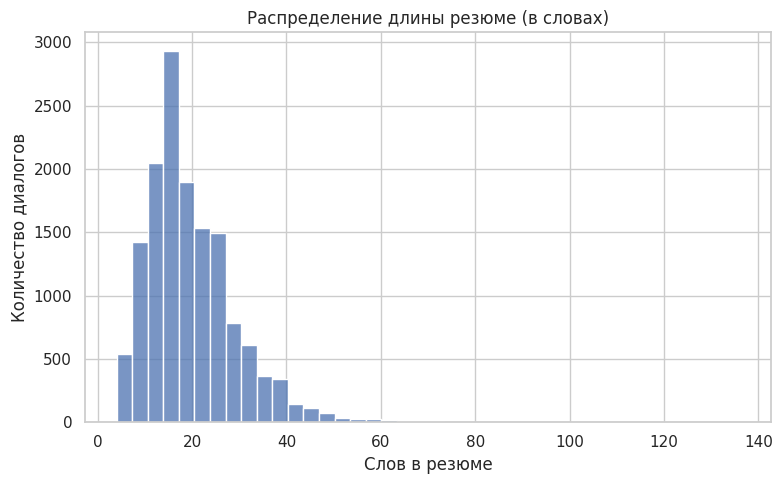

In [16]:
# Гистограмма длины резюме в словах
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df_all, x="summary_len_words", bins=40, ax=ax)
ax.set_title("Распределение длины резюме (в словах)")
ax.set_xlabel("Слов в резюме")
ax.set_ylabel("Количество диалогов")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "hist_summary_len_words.png"), dpi=150)
plt.show()

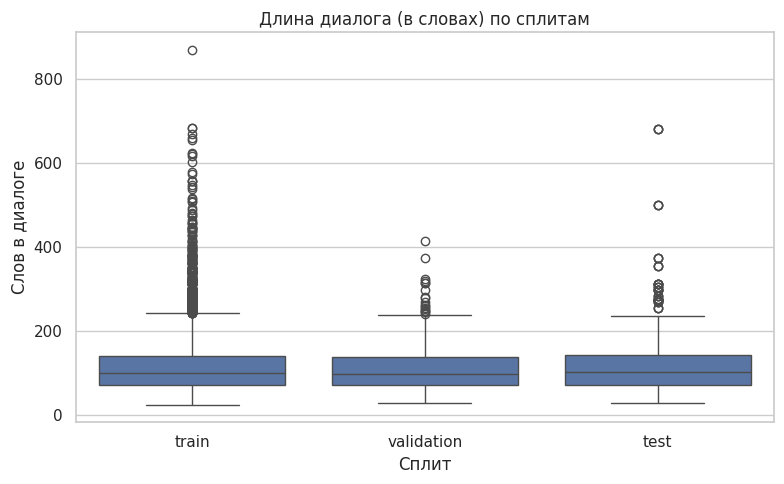

In [17]:
# Boxplot длины диалога по сплитам
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_all, x="split", y="dialogue_len_words", ax=ax)
ax.set_title("Длина диалога (в словах) по сплитам")
ax.set_xlabel("Сплит")
ax.set_ylabel("Слов в диалоге")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "box_dialogue_len_words_by_split.png"), dpi=150)
plt.show()

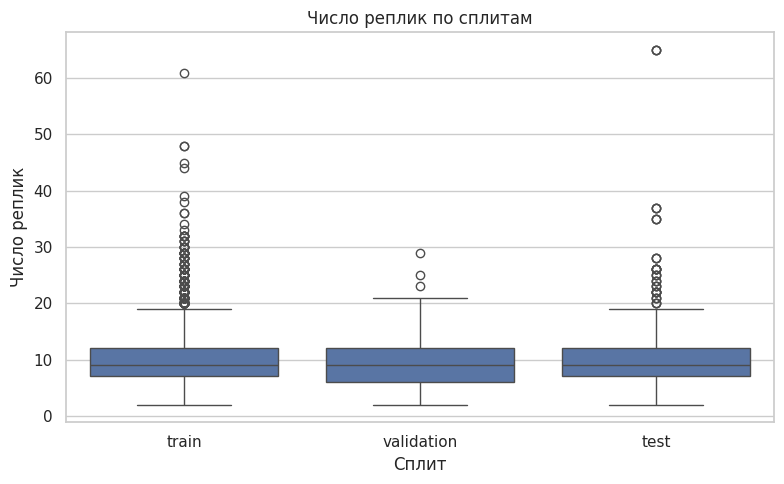

In [18]:
# Распределение числа реплик по сплитам
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_all, x="split", y="num_utterances", ax=ax)
ax.set_title("Число реплик по сплитам")
ax.set_xlabel("Сплит")
ax.set_ylabel("Число реплик")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "box_num_utterances_by_split.png"), dpi=150)
plt.show()

## 6. Случайные диалоги с резюме (для проектирования схемы интентов)

In [19]:
sample_size = 10
sample_df = df_all.sample(n=min(sample_size, len(df_all)), random_state=RANDOM_SEED)

for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    print(f"=== Пример {i} | split={row.split} | id={row.id} ===")
    print("Диалог:")
    print(row.dialogue)
    print("\nРезюме:")
    print(row.summary)
    if getattr(row, "topic", ""):
        print("\nТема:", row.topic)
    print("\n" + "-" * 80 + "\n")

=== Пример 1 | split=train | id=train_8630 ===
Диалог:
#Person1#: Не могли бы вы сказать мне время последнего рейса в Гонконг сегодня вечером?
#Person2#: Есть один в 10:15, но я думаю, он полностью забронирован.
#Person1#: Тогда когда завтра утром будет первый самолет?
#Person2#: Первый самолет вылетает в 8:15.
#Person1#: Не могли бы вы сказать мне, когда он прибудет, чтобы я мог попросить моего секретаря прийти и встретиться со мной?
#Person2#: Он прибывает в 11:15, но, возможно, немного поздно из-за плохой погоды.
#Person1#: Ну, не могли бы вы сообщить мне, есть ли какие-либо изменения на этом рейсе, я был бы признателен.
#Person2#: Да, конечно. Какой у тебя номер комнаты?
#Person1#: 108. Спасибо.

Резюме:
#Person1# спрашивает #Person2# о расписании самолетов. #Person2# говорит, что #Person2# сообщит #Person1#, если будут какие-либо изменения на рейсе.

Тема: самолет

--------------------------------------------------------------------------------

=== Пример 2 | split=train | id=tra

## 7. Предварительные наблюдения

Раздел заполнен после запуска ноутбука, просмотра таблиц, графиков и случайных примеров диалогов.

- **Структура диалогов:** датасет `dialogsum-ru` содержит три сплита: `train` — 12 460 примеров, `validation` — 500 примеров, `test` — 1 500 примеров. Диалоги представлены как последовательности реплик с явными маркерами участников. В таблице начальных токенов почти все диалоги начинаются с маркера `#Person1#:` — 14 434 случая из 14 460, также встречаются варианты `#Человек1#:` и `#Лицо1#:`. Это показывает, что структура реплик в целом регулярная, но есть небольшие различия в формате обозначения участников.

- **Средняя длина:** среднее число реплик в диалоге близко во всех сплитах: около 9.49 в `train`, 9.38 в `validation` и 9.71 в `test`; медиана во всех трех сплитах равна 9 репликам. Средняя длина диалога составляет примерно 112.83 слова в `train`, 111.42 слова в `validation` и 115.95 слова в `test`; медианные значения составляют 99, 96.5 и 103.5 слова соответственно. Средняя длина summary составляет примерно 20.28 слова в `train`, 18.5 слова в `validation` и 16.29 слова в `test`; медианные значения составляют 18, 16 и 15 слов соответственно.

- **Возможные сложности разметки интентов:** в данных есть заметный разброс по длине диалогов: максимальная длина достигает 869 слов в `train`, 415 слов в `validation` и 680 слов в `test`, поэтому часть примеров может быть значительно сложнее для классификации интента всего диалога. Также возможны сложности из-за длинных диалогов с несколькими микротемами, неоднозначного основного намерения, а также из-за различий в формате маркеров участников (`#Person1#:`, `#Человек1#:`, `#Лицо1#:`). Summary в среднем короткие, поэтому они могут быть полезны как вспомогательный сигнал, но не всегда будут полностью отражать все намерения внутри диалога.

- **Идеи для следующего шага:** следующим этапом стоит вручную просмотреть пилотную выборку диалогов, например 50–100 примеров, отдельно обращая внимание на короткие, типичные и длинные диалоги. На основе этой выборки можно сформулировать первичную схему интентов и решить, будет ли у каждого диалога один основной интент или потребуется учитывать смешанные/множественные интенты. Также имеет смысл зафиксировать правила нормализации маркеров участников и подготовить baseline через перевод русскоязычных диалогов на английский язык с применением англоязычной модели классификации.